SpendDNA: Personal Finance Analytics Using Python and **Pandas**

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Data set for DADS June.csv to Data set for DADS June.csv


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         1328 non-null   object 
 1   Time         1328 non-null   object 
 2   Description  1328 non-null   object 
 3   Type         1328 non-null   object 
 4   Amount       1328 non-null   object 
 5   Balance      1328 non-null   float64
 6   Mode         1328 non-null   object 
 7   Ref          1328 non-null   object 
dtypes: float64(1), object(7)
memory usage: 83.1+ KB
Rows and Columns: (1328, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         1328 non-null   datetime64[ns]
 1   Time         1328 non-null   object        
 2   Description  1328 non-null   object        
 3   Type         1328 non-null   object  

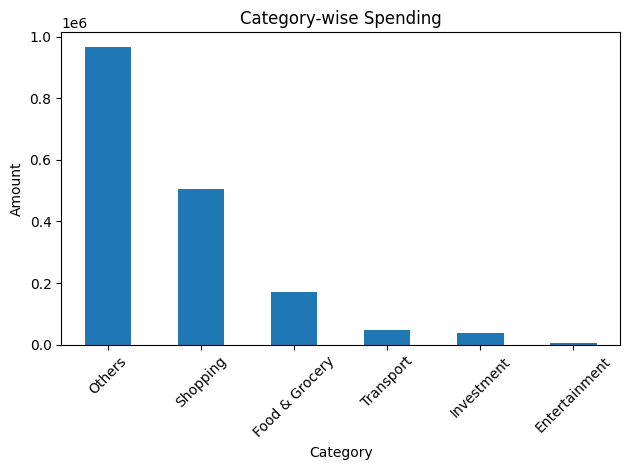

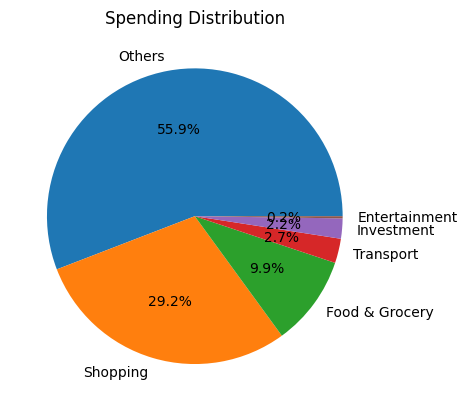

In [29]:
import pandas as pd
import numpy as np
df = pd.read_csv("Data set for DADS June.csv")
df.head()
df.info()
print("Rows and Columns:", df.shape)
df.isnull().sum()
df.head(10)
df.columns
df["Date"] = pd.to_datetime(df["Date"], format="mixed", dayfirst=True)
df["Date"].head(20)
df["Amount"] = (
    df["Amount"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace("Rs.", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")
df.info()
print(df["Amount"].head(10).to_list())
df["Month"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()

df[["Date", "Month", "Day", "Weekday"]].head()
print(df["Type"].value_counts())
print(df["Mode"].value_counts())
print(df["Description"].head(20).to_list())
def categorize(desc):
    desc = str(desc).upper()

    if "SWIGGY" in desc or "ZEPTO" in desc or "BLINKIT" in desc or "STARBUCKS" in desc or "TRUFFLES" in desc:
        return "Food & Grocery"

    elif "UBER" in desc or "OLA" in desc or "BMTC" in desc:
        return "Transport"

    elif "FLIPKART" in desc or "AMAZON" in desc:
        return "Shopping"

    elif "GROWW" in desc:
        return "Investment"

    elif "SALARY" in desc:
        return "Salary"

    elif "MOVIE" in desc or "BMS" in desc:
        return "Entertainment"

    else:
        return "Others"

df["Category"] = df["Description"].apply(categorize)

df[["Description", "Category"]].head(20)
category_count = df["Category"].value_counts()
print(category_count)
debit_df = df[df["Type"].isin(["DR", "Debit"])]

spending = debit_df.groupby("Category")["Amount"].sum().sort_values(ascending=False)

print(spending)
monthly_spending = debit_df.groupby("Month")["Amount"].sum()

print(monthly_spending)
top_merchants = (
    debit_df.groupby("Description")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_merchants)
highest = debit_df.loc[debit_df["Amount"].idxmax()]

print(highest)
daily_spending = debit_df.groupby("Date")["Amount"].sum()

print("Average Daily Spending:", daily_spending.mean())
mode_spending = debit_df.groupby("Mode")["Amount"].sum()

print(mode_spending)
import matplotlib.pyplot as plt

spending.plot(kind="bar")
plt.title("Category-wise Spending")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

spending.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Spending Distribution")
plt.show()

Conclusion:

This project analyzed 1,328 financial transactions using Python and the Pandas library. The dataset was cleaned by converting date and amount fields into appropriate data types and checking for missing values. Additional features such as month, day, weekday, and transaction category were created to support the analysis. The results showed that the majority of transactions were made through UPI, highlighting the user's strong preference for digital payments. The highest spending occurred in the "Others" and "Shopping" categories, while March recorded the maximum monthly expenditure. The analysis also identified the top merchants, highest-value transaction, and average daily spending. Overall, the project demonstrates how data analytics can transform raw banking transaction data into meaningful insights that help users understand spending patterns and make better financial decisions.